# Python Lesson 41: Gradient Descent

**Concept page:** `wiki/concepts/gradient-descent.md` · **Area:** optimization

**You will be able to:**
- implement GD in one and two variables
- study the learning rate
- see local minima and compare starts

*How to use:* run the cells top to bottom, read the output, then try the **Exercises** in the empty cells before opening the **Solutions** section at the bottom.

In [1]:
import numpy as np
import sympy as sp
import matplotlib
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline

## 1. One variable: f(x)=e^x − ln x

In [2]:
def gd1(df,x0,lr,n):
    xs=[x0]
    for _ in range(n): xs.append(xs[-1]-lr*df(xs[-1]))
    return np.array(xs)
df=lambda x:np.exp(x)-1/x
path=gd1(df,0.05,0.005,300); print(path[:4], path[-1])   # -> 0.5671

[0.05   0.1447 0.1735 0.1964] 0.5669879173936623


## 2. Learning-rate experiment

In [3]:
for lr in (0.001,0.005,0.05,0.3):
    p=gd1(df,0.5,lr,100); print(lr, p[-1], "(diverged)" if not np.isfinite(p[-1]) or abs(p[-1])>5 else "")

0.001 0.5270574862846187 
0.005 0.5617883440654936 
0.05 0.5671432904097379 
0.3 0.5671432904097838 


## 3. Two variables on the heat function

[-0.1134 -0.0935]
[4. 4.] 73.62222222222222


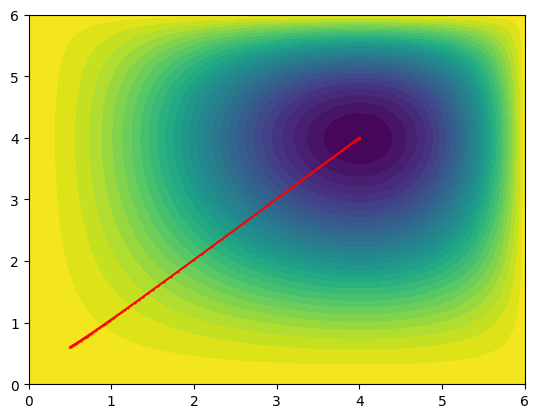

In [4]:
f=lambda x,y:85-(1/90)*x**2*(x-6)*y**2*(y-6)
def grad(x,y): return np.array([-(1/90)*(3*x**2-12*x)*y**2*(y-6), -(1/90)*x**2*(x-6)*(3*y**2-12*y)])
p=np.array([0.5,0.6]); print(grad(*p))      # (-0.1134, -0.0935)
traj=[p.copy()]
for _ in range(2000): p=p-0.05*grad(*p); traj.append(p.copy())
traj=np.array(traj); print(traj[-1], f(*traj[-1]))
X,Y=np.meshgrid(np.linspace(0,6,100),np.linspace(0,6,100)); plt.contourf(X,Y,f(X,Y),30); plt.plot(*traj.T,'r.-',ms=1); plt.show()

## 4. Local minima: 1-D function with two valleys

In [5]:
g=lambda x:x**4-3*x**3+2; dg=lambda x:4*x**3-9*x**2
for s in (-1,1,3): print(s, gd1(dg,s,0.01,2000)[-1])

-1 -0.005445227373559585
1 2.2499999999999987
3 2.2500000000000013


## Cambodian textbook corner (កម្មវិធីសិក្សាកម្ពុជា)
The textbooks give the optimum analytically (zero slope); GD is for functions where f'=0 cannot be solved by hand.

In [6]:
print(gd1(lambda x:2*(x-4),0,0.3,30)[-1])

3.999999999995388


## Exercises

**Exercise 1.** Run GD on f(x)=(x-3)^2 from x=0 with lr=0.1 for 50 steps (result≈3).

In [7]:
# your code here

**Exercise 2.** Find a learning rate that makes GD on x^2 diverge (hint lr>1).

In [8]:
# your code here

## Solutions
*(Try the exercises first!)*

In [9]:
# Solution 1
p=gd1(lambda x:2*(x-3),0,0.1,50); print(p[-1]); assert abs(p[-1]-3)<1e-3

2.9999571825692186


In [10]:
# Solution 2
p=gd1(lambda x:2*x,1,1.1,50); assert abs(p[-1])>10